In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# ---- Design system: a small, consistent palette and helper functions ----
NAVY  = "#1B263B"   # headlines, strong text
GOLD  = "#E0B589"   # accent (1st class)
TEAL  = "#2A9D8F"   # primary positive / survived
CORAL = "#E76F51"   # primary negative / did not survive
GREY  = "#8D99AE"   # secondary text, kickers
BG    = "#FAFAFA"   # neutral background

plt.rcParams.update({'font.family': 'DejaVu Sans', 'figure.facecolor': BG, 'axes.facecolor': BG})

def add_header(fig, kicker, headline):
    """Adds a small grey 'kicker' label and a bold headline that states the finding."""
    fig.text(0.07, 0.95, kicker.upper(), fontsize=9.5, color=GREY, fontweight='bold', va='top')
    fig.text(0.07, 0.89, headline, fontsize=16, color=NAVY, fontweight='bold', va='top', linespacing=1.4)

def strip_spines(ax, keep=()):
    for spine in ['top', 'right', 'left', 'bottom']:
        if spine not in keep:
            ax.spines[spine].set_visible(False)

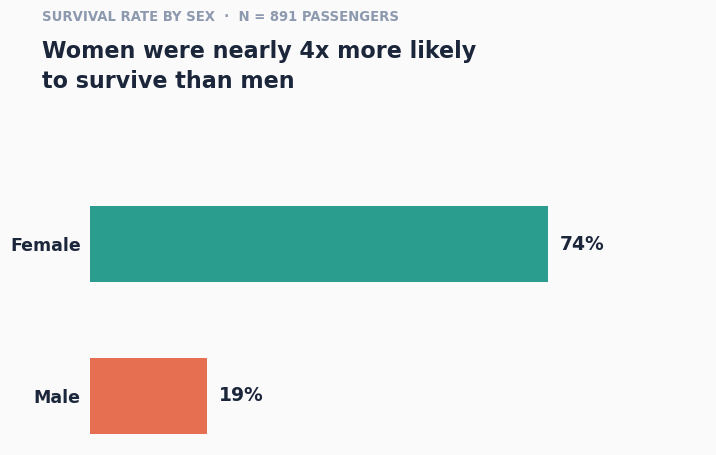

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
fig.subplots_adjust(top=0.58, left=0.13, right=0.9, bottom=0.08)

rates = df.groupby('Sex')['Survived'].mean().reindex(['male', 'female']) * 100
bars = ax.barh(['Male', 'Female'], rates, color=[CORAL, TEAL], height=0.5, zorder=3)

strip_spines(ax)
ax.tick_params(left=False, bottom=False)
ax.set_xticks([])
ax.set_yticks([0, 1])
ax.set_yticklabels(['Male', 'Female'], fontsize=12.5, color=NAVY, fontweight='bold')
ax.set_xlim(0, 100)
for bar, val in zip(bars, rates):
    ax.text(val + 2, bar.get_y() + bar.get_height()/2, f"{val:.0f}%",
            va='center', fontsize=13.5, fontweight='bold', color=NAVY)

add_header(fig, "Survival rate by sex  ·  n = 891 passengers",
           "Women were nearly 4x more likely\nto survive than men")
plt.show()

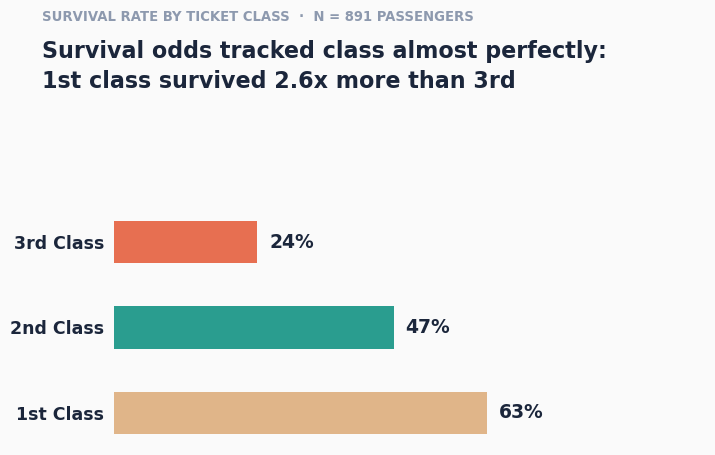

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
fig.subplots_adjust(top=0.55, left=0.16, right=0.9, bottom=0.08)

rates = df.groupby('Pclass')['Survived'].mean() * 100
colors = [GOLD, TEAL, CORAL]
bars = ax.barh(['1st Class', '2nd Class', '3rd Class'], rates.values, color=colors, height=0.5, zorder=3)

strip_spines(ax)
ax.tick_params(left=False, bottom=False)
ax.set_xticks([])
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(['1st Class', '2nd Class', '3rd Class'], fontsize=12.5, color=NAVY, fontweight='bold')
ax.set_xlim(0, 100)
for bar, val in zip(bars, rates.values):
    ax.text(val + 2, bar.get_y() + bar.get_height()/2, f"{val:.0f}%",
            va='center', fontsize=13.5, fontweight='bold', color=NAVY)

add_header(fig, "Survival rate by ticket class  ·  n = 891 passengers",
           "Survival odds tracked class almost perfectly:\n1st class survived 2.6x more than 3rd")
plt.show()

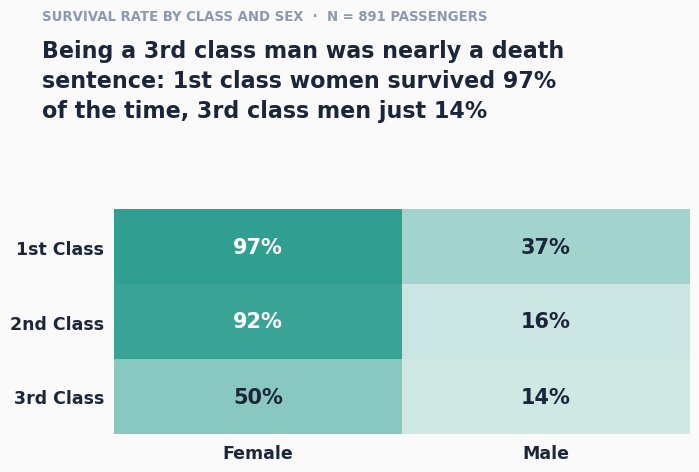

In [5]:
pivot = df.pivot_table(index='Pclass', columns='Sex', values='Survived', aggfunc='mean')[['female', 'male']] * 100
cmap = LinearSegmentedColormap.from_list('navy_scale', ['#EAF4F2', TEAL])

fig, ax = plt.subplots(figsize=(8, 5))
fig.subplots_adjust(top=0.55, left=0.16, right=0.88, bottom=0.1)
ax.imshow(pivot.values, cmap=cmap, vmin=0, vmax=100, aspect='auto')

ax.set_xticks([0, 1]); ax.set_xticklabels(['Female', 'Male'], fontsize=12.5, color=NAVY, fontweight='bold')
ax.set_yticks([0, 1, 2]); ax.set_yticklabels(['1st Class', '2nd Class', '3rd Class'], fontsize=12.5, color=NAVY, fontweight='bold')
ax.tick_params(left=False, bottom=False)
strip_spines(ax)

for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val = pivot.values[i, j]
        ax.text(j, i, f"{val:.0f}%", ha='center', va='center', fontsize=15,
                fontweight='bold', color='white' if val > 55 else NAVY)

add_header(fig, "Survival rate by class and sex  ·  n = 891 passengers",
           "Being a 3rd class man was nearly a death\nsentence: 1st class women survived 97%\nof the time, 3rd class men just 14%")
plt.show()